# GANisme — 04. Modèle n°1 : DCGAN, portraits en 64×80

Premier modèle du projet, et **point de référence** pour tous les suivants. Le choix du DCGAN est discuté dans la
conversation de cadrage : c'est l'architecture convolutive la plus simple qui fonctionne (cf. veille, question 12),
entièrement explicable, rapide à entraîner, et contre laquelle chaque amélioration pourra être mesurée.

| | |
|---|---|
| Données | 3 448 portraits (train), format 4:5, 64×80 px (notebook 03) |
| Code | `src/models.py` (architecture), `src/train.py` (boucle d'entraînement et suivi) |
| Commande | `python src/train.py --genre portrait --res 64 --epochs 500 --name dcgan_portrait_64` |
| Évaluation | protocole du notebook 03 : 3 448 images générées à graine fixe, toutes les 25 époques |

Ce notebook n'entraîne pas le modèle : il **analyse le run** enregistré dans `runs/dcgan_portrait_64/`.

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import torch
from PIL import Image
from matplotlib_inline.backend_inline import set_matplotlib_formats

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import dataset as ds          # noqa: E402
import metrics as mt          # noqa: E402
import train as tr            # noqa: E402
from models import Discriminator, Generator, base_grid, count_params   # noqa: E402

RUN = "dcgan_portrait_64"
RUN_DIR = ROOT / "runs" / RUN
FIG_DIR = ROOT / "reports" / "figures"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
set_matplotlib_formats("jpeg", pil_kwargs={"quality": 88})

CAT = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
MAIN, OTHER = CAT[0], "#c3c2b7"
INK, INK2, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "DejaVu Sans", "Arial"],
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlecolor": INK, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": INK2, "axes.edgecolor": OTHER,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "legend.frameon": False, "lines.linewidth": 2,
})


def save(fig, name):
    fig.savefig(FIG_DIR / f"{RUN}_{name}.png")


cfg = json.loads((RUN_DIR / "config.json").read_text(encoding="utf-8"))
hist = pd.read_csv(RUN_DIR / "history.csv")
ev = pd.read_csv(RUN_DIR / "eval.csv")
SIZE = tuple(cfg["size"])
baselines = pd.read_csv(ROOT / "reports" / "metrics" / "baselines.csv")
bl = baselines[(baselines["genre"] == cfg["genre"]) & (baselines["résolution"] == f"{SIZE[0]}×{SIZE[1]}")].set_index("baseline")
print(f"{RUN} : {cfg['genre']} {SIZE[0]}×{SIZE[1]}, {cfg['epochs']} époques, {len(ev)} évaluations")

dcgan_portrait_64 : portrait 64×80, 500 époques, 21 évaluations


## 1. L'architecture

On instancie les deux réseaux avec la configuration du run et on fait passer un batch pour afficher la forme du
tenseur à la sortie de chaque couche.

In [2]:
base = base_grid(SIZE, cfg["n_up"])
G = Generator(cfg["nz"], cfg["ngf"], base, cfg["n_up"])
D = Discriminator(cfg["ndf"], base, cfg["n_up"])


def layer_table(model, x):
    rows = []
    for layer in model.net:
        x = layer(x)
        n = sum(p.numel() for p in layer.parameters())
        rows.append({"couche": layer.__class__.__name__, "sortie": " × ".join(map(str, x.shape[1:])),
                     "paramètres": f"{n:,}".replace(",", " ") if n else ""})
    return pd.DataFrame(rows)


with torch.no_grad():
    tg = layer_table(G, torch.randn(2, cfg["nz"], 1, 1))
    td = layer_table(D, torch.randn(2, 3, SIZE[1], SIZE[0]))
print(f"Grille de départ (h × l) : {base[0]} × {base[1]} | G : {count_params(G):,} paramètres | D : {count_params(D):,} paramètres".replace(",", " "))
display(tg.style.set_caption("Générateur"))
display(td.style.set_caption("Discriminateur"))

Grille de départ (h × l) : 5 × 4 | G : 3 781 504 paramètres | D : 2 767 616 paramètres


,couche,sortie,paramètres
0,ConvTranspose2d,512 × 5 × 4,1 024 000
1,BatchNorm2d,512 × 5 × 4,1 024
2,ReLU,512 × 5 × 4,
3,ConvTranspose2d,256 × 10 × 8,2 097 152
4,BatchNorm2d,256 × 10 × 8,512
5,ReLU,256 × 10 × 8,
6,ConvTranspose2d,128 × 20 × 16,524 288
7,BatchNorm2d,128 × 20 × 16,256
8,ReLU,128 × 20 × 16,
9,ConvTranspose2d,64 × 40 × 32,131 072


,couche,sortie,paramètres
0,Conv2d,64 × 40 × 32,3 072
1,LeakyReLU,64 × 40 × 32,
2,Conv2d,128 × 20 × 16,131 072
3,BatchNorm2d,128 × 20 × 16,256
4,LeakyReLU,128 × 20 × 16,
5,Conv2d,256 × 10 × 8,524 288
6,BatchNorm2d,256 × 10 × 8,512
7,LeakyReLU,256 × 10 × 8,
8,Conv2d,512 × 5 × 4,2 097 152
9,BatchNorm2d,512 × 5 × 4,1 024


### Hyperparamètres

In [3]:
pd.Series({k: v for k, v in cfg.items() if k not in ("name",)}, name="valeur").to_frame()

,valeur
genre,portrait
res,64
epochs,500
batch_size,128
lr_g,0.0002
lr_d,0.0002
beta1,0.5
beta2,0.999
nz,100
ngf,64


**Lecture** — le générateur (3,8 M de paramètres) part d'une grille 5×4 à 512 canaux et double la résolution à chaque
bloc en divisant les canaux par deux, jusqu'à l'image 3×80×64. Le discriminateur (2,8 M) fait le chemin inverse et
résume l'image en **un seul score**. Les hyperparamètres sont ceux de l'article DCGAN (Adam, lr = 2·10⁻⁴, β₁ = 0,5,
batch de 128, z de dimension 100), sans réglage : c'est volontaire pour un modèle de référence. Seul ajout :
le **miroir horizontal** aléatoire, qui double la variété des portraits sans les dénaturer.

## 2. Dynamique de l'entraînement

Dans un GAN, **les pertes ne mesurent pas la qualité** (cf. veille, questions 7 et 9) : elles décrivent le rapport de
force entre les deux réseaux. On les lit avec les sorties du discriminateur :
- `D(x)` : probabilité « réel » attribuée aux vraies images ;
- `D(G(z))` : probabilité « réel » attribuée aux images générées.

À l'équilibre théorique (Nash), les deux valent 0,5 et les pertes valent `log 4 ≈ 1,39` (D) et `log 2 ≈ 0,69` (G).

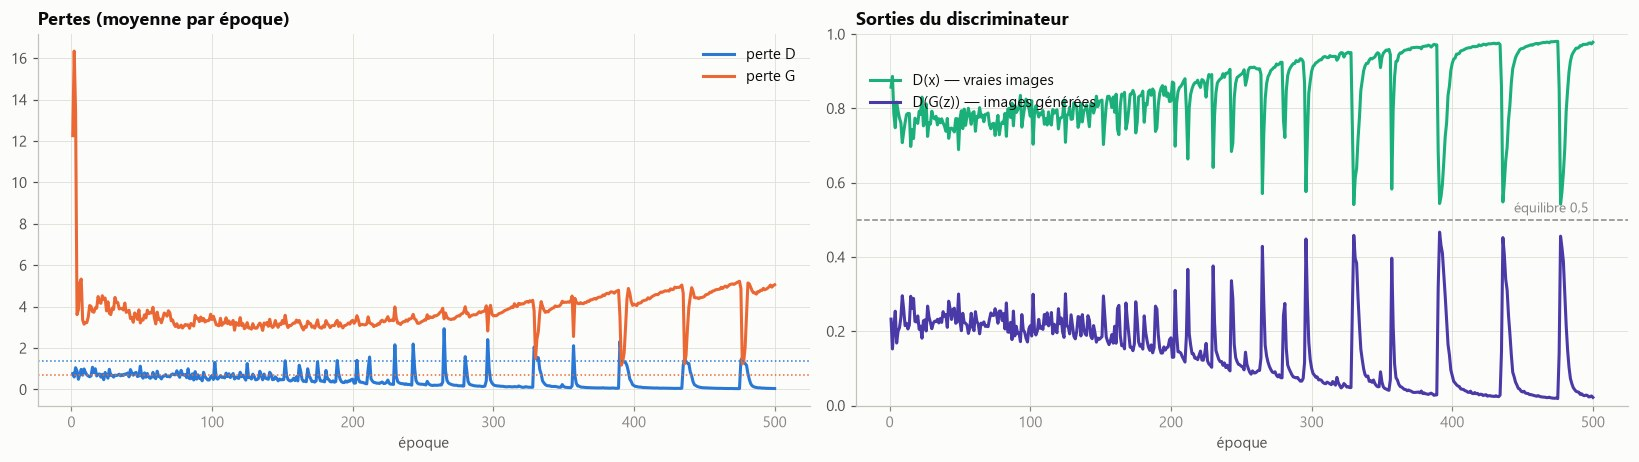

Temps moyen par époque : 1.60 s — 13 000 itérations au total


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.3))
ax = axes[0]
ax.plot(hist["epoch"], hist["loss_d"], color=CAT[0], label="perte D")
ax.plot(hist["epoch"], hist["loss_g"], color=CAT[1], label="perte G")
ax.axhline(np.log(4), color=CAT[0], ls=":", lw=1); ax.axhline(np.log(2), color=CAT[1], ls=":", lw=1)
ax.set_title("Pertes (moyenne par époque)"); ax.set_xlabel("époque"); ax.legend()
ax = axes[1]
ax.plot(hist["epoch"], hist["d_real"], color=CAT[2], label="D(x) — vraies images")
ax.plot(hist["epoch"], hist["d_fake"], color=CAT[6], label="D(G(z)) — images générées")
ax.axhline(0.5, color=MUTED, ls="--", lw=1); ax.text(hist["epoch"].max(), 0.52, "équilibre 0,5 ", ha="right", fontsize=9, color=MUTED)
ax.set_ylim(0, 1); ax.set_title("Sorties du discriminateur"); ax.set_xlabel("époque"); ax.legend(loc="upper left", bbox_to_anchor=(0, 0.93))
plt.tight_layout()
save(fig, "01_dynamics")
plt.show()
print(f"Temps moyen par époque : {hist['seconds'].iloc[1:].mean():.2f} s — {hist['iters'].iloc[-1]:,} itérations au total".replace(",", " "))

**Observations — le discriminateur prend progressivement le dessus**

- Jusqu'à l'époque ~200, le jeu est équilibré : `D(x)` ≈ 0,8 et `D(G(z))` ≈ 0,2, avec des pertes stables.
- Ensuite le discriminateur **gagne de plus en plus nettement** : à la fin, il attribue 0,98 aux vraies images et 0,02
  aux fausses, sa perte tombe sous 0,1 et celle du générateur monte de 3 à 5. C'est exactement le déséquilibre
  « discriminateur trop fort » décrit dans la veille (question 9) : le générateur reçoit un signal de moins en moins
  utile.
- Les **pics périodiques** sont des crises : le générateur trouve une faille, `D(G(z))` remonte brusquement vers 0,45,
  puis le discriminateur se corrige en quelques époques. Ce motif d'oscillation, de plus en plus marqué, est typique
  d'un discriminateur qui commence à **apprendre le train par cœur** — un risque identifié dès le notebook 03 avec
  seulement 3 448 images.
- Coût : 1,6 s par époque, 13 000 itérations, **13 minutes d'entraînement** (22 minutes avec les évaluations).

## 3. Les métriques au fil de l'entraînement

Les lignes horizontales sont les **faux générateurs** du notebook 03 : elles situent le modèle sur l'échelle de lecture.

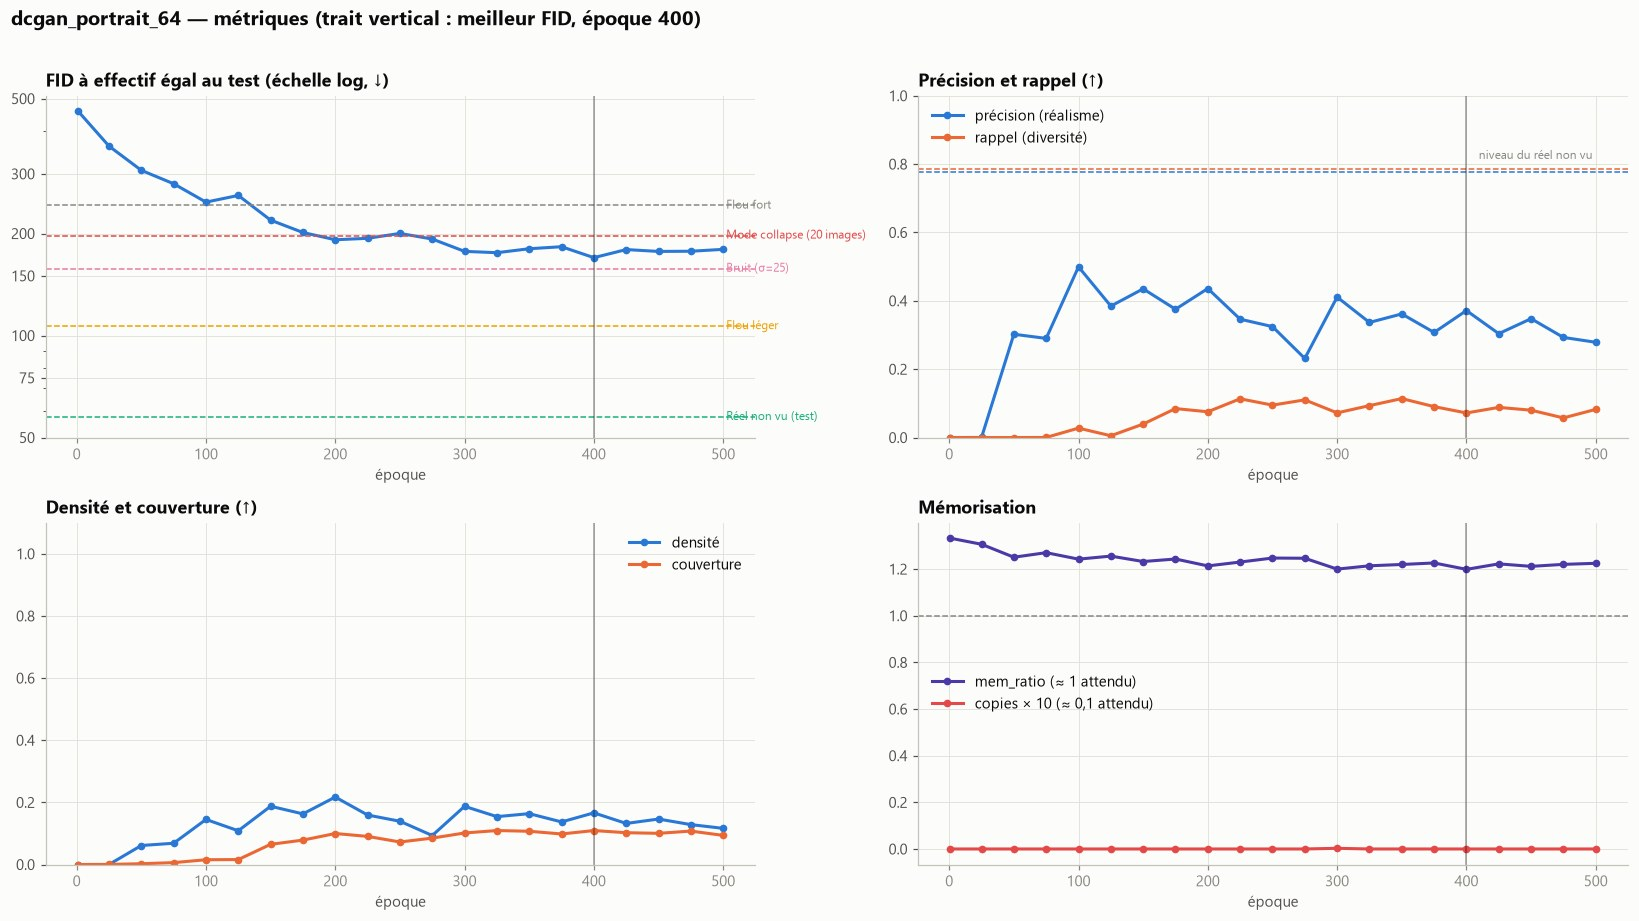

,epoch,FID,FID_ntest,KID_x1000,precision,recall,density,coverage,mem_ratio,copies
0,1,454.740,459.725,571.510,0.000,0.000,0.000,0.000,1.332,0.0
1,25,343.089,362.191,393.232,0.000,0.000,0.000,0.000,1.306,0.0
2,50,280.700,307.224,313.467,0.302,0.000,0.061,0.003,1.251,0.0
3,75,251.036,280.446,274.259,0.290,0.000,0.068,0.006,1.270,0.0
4,100,211.985,247.542,212.924,0.499,0.028,0.145,0.015,1.242,0.0
5,125,220.852,259.030,222.663,0.385,0.005,0.109,0.016,1.256,0.0
6,150,180.043,219.012,173.317,0.435,0.039,0.187,0.065,1.232,0.0
7,175,159.938,201.375,150.348,0.375,0.085,0.163,0.079,1.243,0.0
8,200,153.716,191.692,144.407,0.436,0.075,0.217,0.100,1.214,0.0
9,225,151.929,193.568,143.484,0.346,0.113,0.159,0.090,1.230,0.0


In [5]:
best = ev.loc[ev["FID"].idxmin()]
fig, axes = plt.subplots(2, 2, figsize=(15, 8.5))

ax = axes[0, 0]
ax.plot(ev["epoch"], ev["FID_ntest"], color=MAIN, marker="o", ms=4, label=RUN)
for lbl, c in [("Réel non vu (test)", CAT[2]), ("Flou léger", CAT[3]), ("Bruit (σ=25)", CAT[4]),
               ("Mode collapse (20 images)", CAT[7]), ("Flou fort", MUTED)]:
    ax.axhline(bl.loc[lbl, "FID_ntest"], color=c, ls="--", lw=1)
    ax.text(ev["epoch"].max(), bl.loc[lbl, "FID_ntest"], f" {lbl}", va="center", fontsize=8, color=c)
ax.set_yscale("log"); ax.yaxis.set_major_formatter(mtick.ScalarFormatter()); ax.yaxis.set_minor_formatter(mtick.NullFormatter())
ax.set_yticks([50, 75, 100, 150, 200, 300, 500])
ax.set_title("FID à effectif égal au test (échelle log, ↓)"); ax.set_xlabel("époque")
ax.axvline(best["epoch"], color=INK, lw=1, alpha=0.4)

ax = axes[0, 1]
ax.plot(ev["epoch"], ev["precision"], color=CAT[0], marker="o", ms=4, label="précision (réalisme)")
ax.plot(ev["epoch"], ev["recall"], color=CAT[1], marker="o", ms=4, label="rappel (diversité)")
ax.axhline(bl.loc["Réel non vu (test)", "precision"], color=CAT[0], ls="--", lw=1)
ax.axhline(bl.loc["Réel non vu (test)", "recall"], color=CAT[1], ls="--", lw=1)
ax.text(ev["epoch"].max(), bl.loc["Réel non vu (test)", "recall"] + 0.03, "niveau du réel non vu ", ha="right", fontsize=8, color=MUTED)
ax.set_ylim(0, 1); ax.set_title("Précision et rappel (↑)"); ax.set_xlabel("époque"); ax.legend(loc="upper left")
ax.axvline(best["epoch"], color=INK, lw=1, alpha=0.4)

ax = axes[1, 0]
ax.plot(ev["epoch"], ev["density"], color=CAT[0], marker="o", ms=4, label="densité")
ax.plot(ev["epoch"], ev["coverage"], color=CAT[1], marker="o", ms=4, label="couverture")
ax.set_ylim(0, max(1.1, ev["density"].max() * 1.1)); ax.set_title("Densité et couverture (↑)"); ax.set_xlabel("époque"); ax.legend()
ax.axvline(best["epoch"], color=INK, lw=1, alpha=0.4)

ax = axes[1, 1]
ax.plot(ev["epoch"], ev["mem_ratio"], color=CAT[6], marker="o", ms=4, label="mem_ratio (≈ 1 attendu)")
ax.plot(ev["epoch"], ev["copies"] * 10, color=CAT[7], marker="o", ms=4, label="copies × 10 (≈ 0,1 attendu)")
ax.axhline(1, color=MUTED, ls="--", lw=1)
ax.set_title("Mémorisation"); ax.set_xlabel("époque"); ax.legend()
ax.axvline(best["epoch"], color=INK, lw=1, alpha=0.4)
fig.suptitle(f"{RUN} — métriques (trait vertical : meilleur FID, époque {int(best['epoch'])})",
             x=0.01, ha="left", fontsize=13, fontweight="bold")
plt.tight_layout(rect=(0, 0, 1, 0.97))
save(fig, "02_metrics")
plt.show()

ev[["epoch", "FID", "FID_ntest", "KID_x1000", "precision", "recall", "density", "coverage", "mem_ratio", "copies"]].round(3)

**Observations**

- **Le FID baisse fortement jusqu'à l'époque ~300, puis plafonne** : de 460 à ~175 à effectif égal au test. Le
  meilleur score est atteint à l'époque 400 (**FID 130 ; 170 à effectif égal**). Les 100 dernières époques n'apportent
  plus rien — le plateau coïncide avec la domination du discriminateur.
- Sur l'échelle de lecture, le modèle se situe **entre le « bruit » et le « mode collapse »**, loin du réel non vu (58).
- **La précision (0,3-0,4) est à la moitié du niveau réel (0,78)**, et **le rappel (≈ 0,1) est très faible** : le
  générateur produit des images en partie plausibles, mais ne couvre qu'une petite part de la variété des portraits
  réels. **Le manque de diversité est la principale faiblesse du modèle.** La précision décline même légèrement
  après l'époque 300.
- **Aucune mémorisation** : `mem_ratio` ≈ 1,2 (les images générées sont *plus loin* du train que de vraies œuvres
  nouvelles, parce qu'elles sont moins réalistes) et 0 % de copies. Le discriminateur apprend peut-être le train,
  mais le générateur ne le recopie pas.

## 4. Évolution visuelle à bruit fixe

Les grilles sont générées à chaque évaluation à partir des **mêmes vecteurs latents** : on voit chaque « tableau »
se former. On affiche ici les 16 premières images de chaque grille.

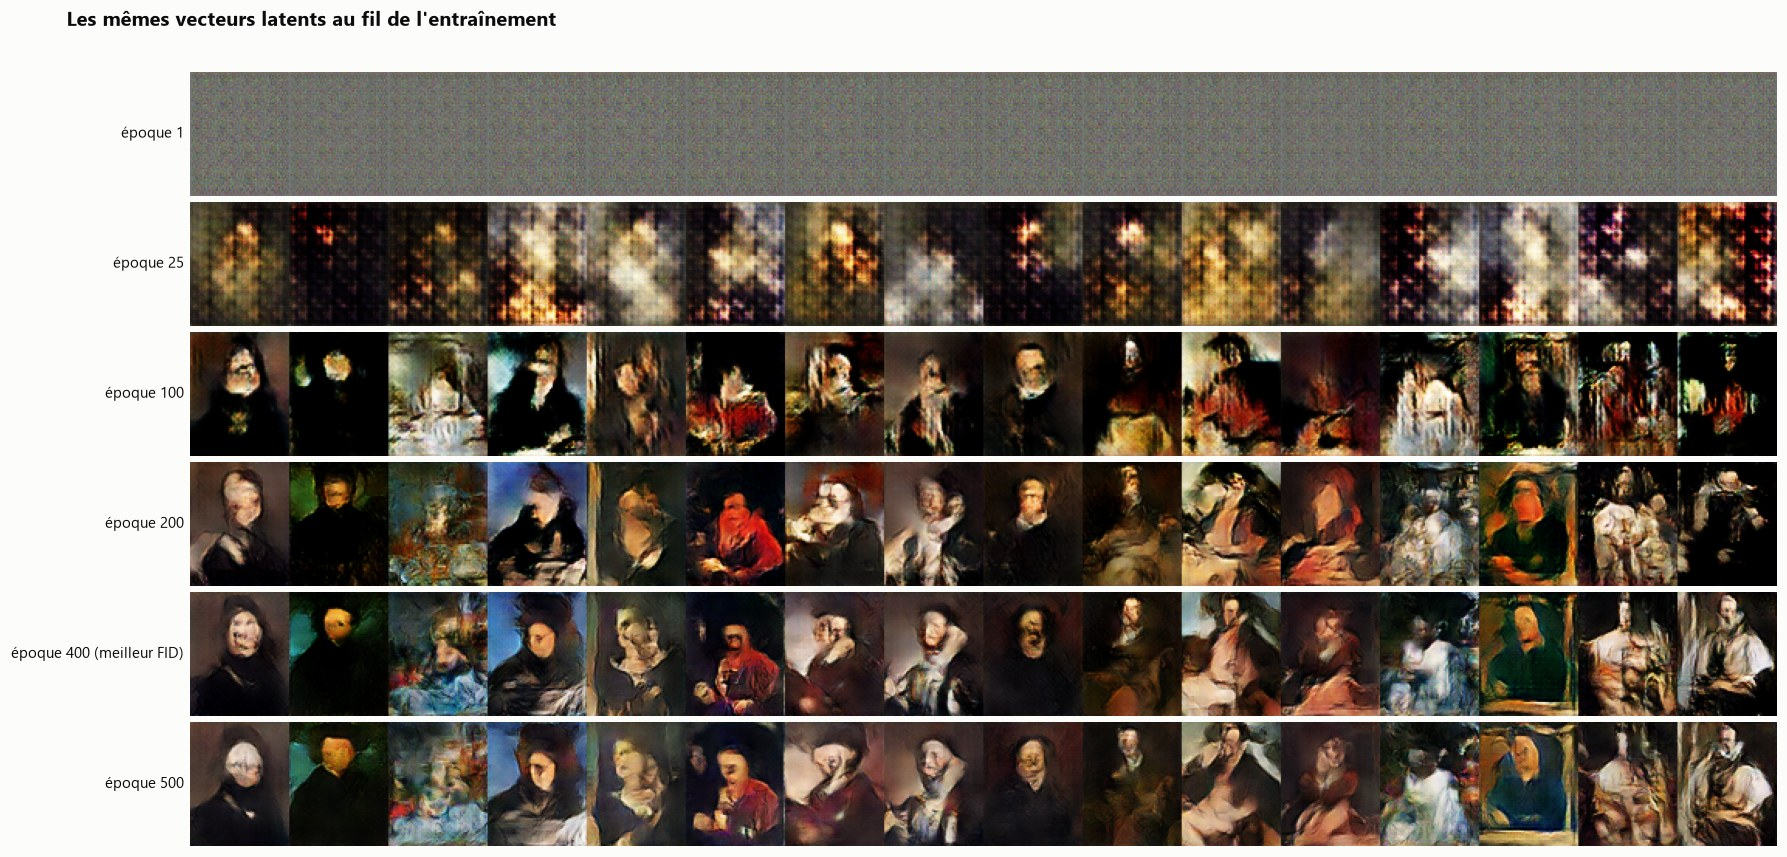

In [6]:
def grid_tiles(path, n=16, ncol=8):
    # Découpe une grille sauvegardée par torchvision (padding 2 px) en tuiles individuelles.
    g = np.asarray(Image.open(path).convert("RGB"))
    w, h, p = SIZE[0], SIZE[1], 2
    return [g[p + (i // ncol) * (h + p): p + (i // ncol) * (h + p) + h, p + (i % ncol) * (w + p): p + (i % ncol) * (w + p) + w]
            for i in range(n)]


epochs_avail = sorted(int(p.stem.split("_")[1]) for p in (RUN_DIR / "samples").glob("epoch_*.png"))
show = sorted({epochs_avail[0], 25, 100, 200, int(best["epoch"]), epochs_avail[-1]} & set(epochs_avail))
fig, axes = plt.subplots(len(show), 1, figsize=(16, 1.25 * len(show) + 0.4))
for ax, e in zip(axes, show):
    tiles = grid_tiles(RUN_DIR / "samples" / f"epoch_{e:04d}.png")
    ax.imshow(np.concatenate(tiles, axis=1)); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    for s in ax.spines.values():
        s.set_visible(False)
    tag = " (meilleur FID)" if e == int(best["epoch"]) else ""
    ax.set_ylabel(f"époque {e}{tag}", rotation=0, ha="right", va="center", fontsize=10, color=INK)
fig.suptitle("Les mêmes vecteurs latents au fil de l'entraînement", x=0.01, ha="left", fontsize=13, fontweight="bold")
plt.tight_layout(rect=(0, 0, 1, 0.97), h_pad=0.4)
save(fig, "03_evolution")
plt.show()

**Observations** — l'apprentissage suit l'ordre attendu : bruit gris (époque 1), damier et taches de lumière
(25 — artefact classique des convolutions transposées), silhouettes sur fond sombre (100), puis de vrais portraits
dès l'époque 200 : buste centré, fond sombre, vêtement, lumière venant du haut. Entre l'époque 400 et la 500, les
images ne changent presque plus : le modèle a convergé vers son plateau.

## 5. Le meilleur checkpoint

On recharge le générateur au meilleur FID et on compare ses images à de vraies peintures du train, à la même
résolution.

Checkpoint de l'époque 400 — FID 130.0


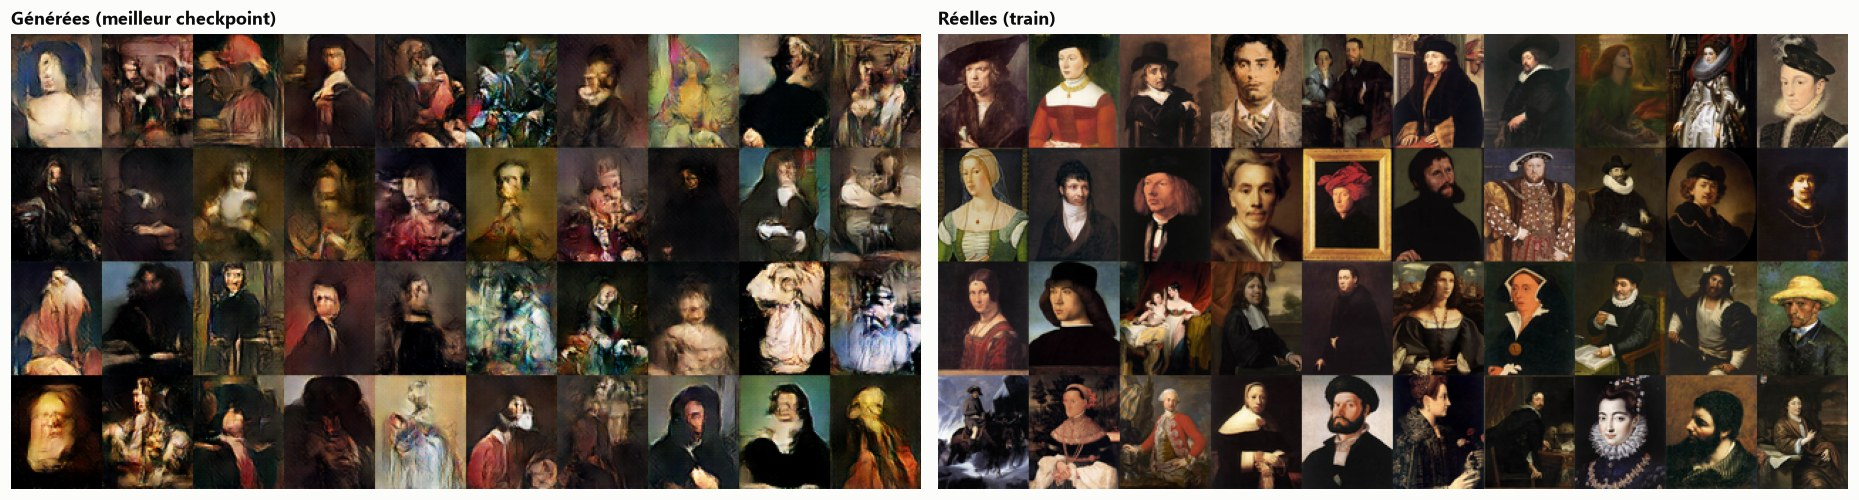

In [7]:
ckpt = torch.load(RUN_DIR / "checkpoints" / "best.pt", map_location=DEVICE, weights_only=True)
G = Generator(cfg["nz"], cfg["ngf"], base, cfg["n_up"]).to(DEVICE)
G.load_state_dict(ckpt["G"])
print(f"Checkpoint de l'époque {ckpt['epoch']} — FID {ckpt['scores']['FID']:.1f}")

z = torch.randn(40, cfg["nz"], generator=torch.Generator().manual_seed(123)).to(DEVICE)
fake = tr.generate(G, z).permute(0, 2, 3, 1).cpu().numpy()
real = ds.load_split(cfg["genre"], "train", SIZE)
real = real[np.random.default_rng(123).choice(len(real), 40, replace=False)]


def mosaic(imgs, ncol=10):
    rows = [np.concatenate(imgs[i:i + ncol], axis=1) for i in range(0, len(imgs), ncol)]
    return np.concatenate(rows, axis=0)


fig, axes = plt.subplots(1, 2, figsize=(17, 7.2))
for ax, imgs, title in [(axes[0], fake, "Générées (meilleur checkpoint)"), (axes[1], real, "Réelles (train)")]:
    ax.imshow(mosaic(list(imgs))); ax.axis("off"); ax.set_title(title)
plt.tight_layout()
save(fig, "04_best_vs_real")
plt.show()

### 5.1 Contrôle visuel de la mémorisation

Pour quelques images générées, on cherche l'image du train la plus proche dans l'espace d'Inception. Si le générateur
recopiait, on retrouverait la même œuvre.

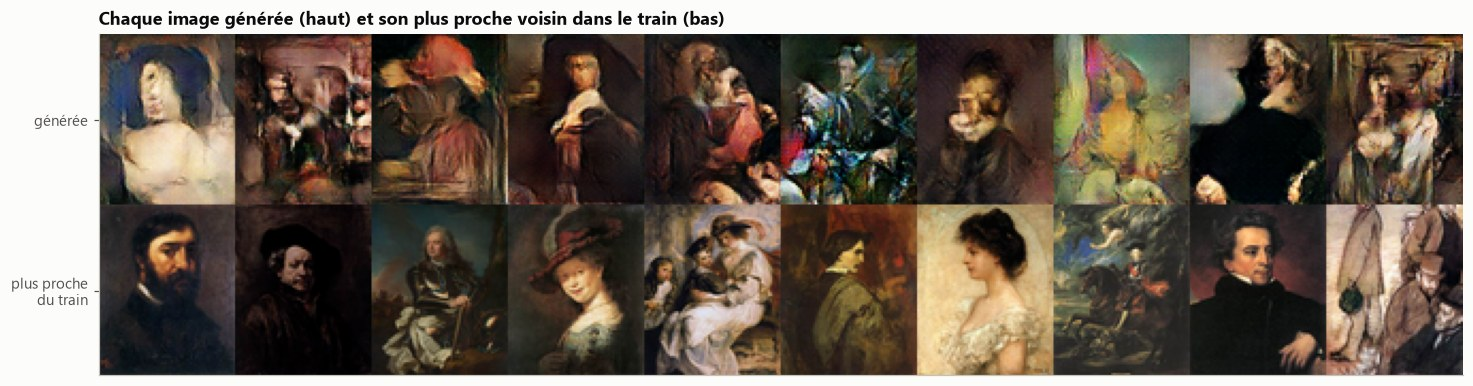

In [8]:
ref = mt.Reference.load_or_compute(cfg["genre"], SIZE, ds.DATASETS / cfg["genre"])
f_fake, _ = mt.extract_features(fake[:10])
d = torch.cdist(torch.from_numpy(f_fake).float(), torch.from_numpy(ref.train).float())
nn_idx = d.argmin(1).numpy()
train_all = ds.load_split(cfg["genre"], "train", SIZE)
fig, ax = plt.subplots(figsize=(16, 4.2))
top = np.concatenate(list(fake[:10]), axis=1)
bottom = np.concatenate([train_all[i] for i in nn_idx], axis=1)
ax.imshow(np.concatenate([top, bottom], axis=0)); ax.set_xticks([]); ax.set_yticks([SIZE[1] / 2, SIZE[1] * 1.5], ["générée", "plus proche\ndu train"])
ax.grid(False)
ax.set_title("Chaque image générée (haut) et son plus proche voisin dans le train (bas)")
save(fig, "05_nearest_neighbors")
plt.show()

### 5.2 Interpolation dans l'espace latent

Autre test de la veille (question 7) : on relie deux vecteurs latents et on génère les images intermédiaires. Des
transitions **progressives** indiquent que le générateur a appris un espace continu de « tableaux possibles » ; des
sauts brusques trahiraient un apprentissage par cœur de quelques images.

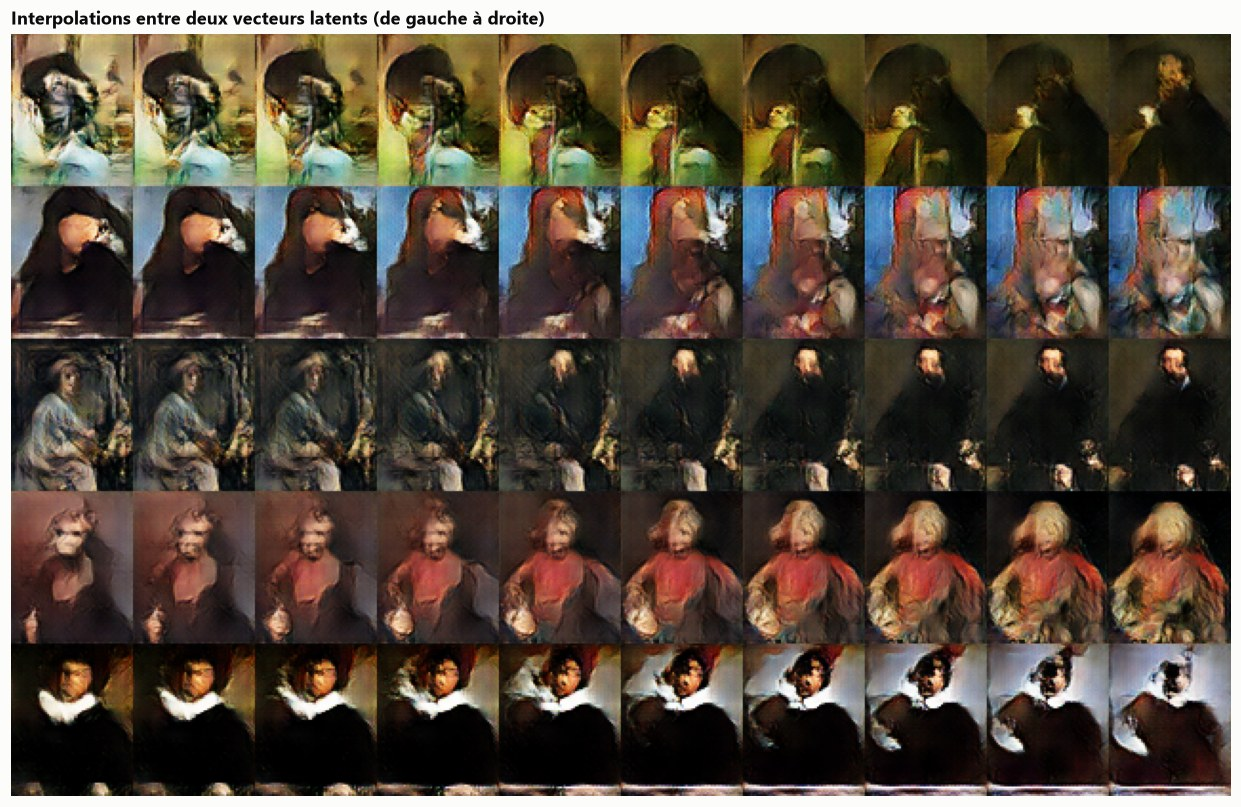

In [9]:
def slerp(a, b, t):
    # Interpolation sphérique : reste à la « bonne distance » de l'origine, comme les vecteurs gaussiens.
    omega = torch.acos((a / a.norm() * b / b.norm()).sum().clamp(-1, 1))
    return (torch.sin((1 - t) * omega) * a + torch.sin(t * omega) * b) / torch.sin(omega)


g = torch.Generator().manual_seed(7)
steps = torch.linspace(0, 1, 10)
rows = []
for _ in range(5):
    a, b = torch.randn(cfg["nz"], generator=g), torch.randn(cfg["nz"], generator=g)
    zs = torch.stack([slerp(a, b, t) for t in steps]).to(DEVICE)
    rows.append(np.concatenate(list(tr.generate(G, zs).permute(0, 2, 3, 1).cpu().numpy()), axis=1))
fig, ax = plt.subplots(figsize=(16, 9))
ax.imshow(np.concatenate(rows, axis=0)); ax.axis("off")
ax.set_title("Interpolations entre deux vecteurs latents (de gauche à droite)")
save(fig, "06_interpolation")
plt.show()

**Observations**

- **L'impression d'ensemble est celle d'un portrait peint** : fond sombre, buste, touches de lumière sur le visage et
  le col, palettes brun-ocre et rouges proches des tableaux réels, texture « de pinceau ». À petite taille, certaines
  images évoquent des esquisses de Rembrandt ou de Goya.
- **Mais les visages sont presque tous déformés ou effacés.** À 64×80, un visage fait une quinzaine de pixels ; c'est
  la structure la plus fine et la plus exigeante (symétrie, yeux, bouche), et c'est la première à échouer. Les
  vêtements et les fonds, plus tolérants, sont bien mieux rendus.
- **Plus proches voisins** : aucune image générée n'est une copie. Le voisin le plus proche partage l'ambiance
  (palette, fond, pose) mais c'est une autre œuvre — ce que confirmait la métrique de mémorisation.
- **Interpolations** : les transitions sont **continues** (un visage tourne, un fond s'éclaircit, un col apparaît
  progressivement), sans saut brutal. Le générateur a appris un espace latent structuré, pas une collection d'images.

## 6. Bilan chiffré

In [10]:
reg = pd.read_csv(ROOT / "reports" / "metrics" / "models.csv")
cols = ["epoch", "FID", "FID_ntest", "KID_x1000", "precision", "recall", "density", "coverage", "mem_ratio", "copies"]
mine = reg[reg["run"] == RUN].set_index("checkpoint")[cols]
refs = bl.loc[["Réel non vu (test)", "Flou léger", "Bruit (σ=25)", "Mode collapse (20 images)", "Flou fort"],
              [c for c in cols if c != "epoch"]]
refs.index = "réf. · " + refs.index
pd.concat([mine, refs]).round(3)

,epoch,FID,FID_ntest,KID_x1000,precision,recall,density,coverage,mem_ratio,copies
best,400.0,129.988,169.740,119.640,0.372,0.072,0.166,0.109,1.199,0.000
last,500.0,137.645,179.586,135.064,0.279,0.082,0.116,0.094,1.225,0.000
réf. · Réel non vu (test),NaN,57.562,57.562,-0.223,0.776,0.785,0.913,0.396,1.000,0.010
réf. · Flou léger,NaN,61.232,106.555,56.554,0.684,0.712,0.268,0.671,1.025,0.029
réf. · Bruit (σ=25),NaN,113.950,157.661,121.322,0.141,0.237,0.037,0.111,1.177,0.001
réf. · Mode collapse (20 images),NaN,196.333,197.167,15.759,1.000,0.006,0.999,0.029,0.001,1.000
réf. · Flou fort,NaN,203.407,241.989,213.972,0.026,0.019,0.005,0.004,1.337,0.000


## 7. Conclusion

**Le DCGAN de référence fonctionne** : en 13 minutes d'entraînement, il produit des images qui ont clairement
l'allure de portraits peints, sans recopier le dataset. Chiffres à retenir (meilleur checkpoint, époque 400) :

| FID | FID_ntest | Précision | Rappel | Mémorisation |
|---|---|---|---|---|
| **130** | **170** (réel : 58) | **0,37** (réel : 0,78) | **0,07** (réel : 0,79) | aucune (`mem_ratio` 1,2 ; 0 % de copies) |

**Deux faiblesses identifiées, chacune mesurable :**

1. **Diversité insuffisante** (rappel ≈ 0,07) : le générateur ne couvre qu'une petite part des portraits réels.
2. **Discriminateur trop fort** à partir de l'époque ~250 (`D(x)` → 0,98) : il apprend le train par cœur et le
   générateur cesse de progresser, d'où le plateau du FID.

**Prochain modèle** — ces deux symptômes sont précisément ceux que traitent les variantes prévues :
- **DiffAugment** (Zhao et al., 2020) : on applique les mêmes augmentations (couleur, translation, découpe) aux images
  réelles *et* générées avant le discriminateur, qui ne peut plus mémoriser le train. C'est le remède direct au
  symptôme n°2 sur un petit dataset ;
- **perte hinge + normalisation spectrale** (ou WGAN-GP) : limite la « force » du discriminateur et donne des
  gradients plus informatifs au générateur, ce qui vise le symptôme n°1.

Pour respecter la règle *une idée par modèle*, le modèle n°2 n'ajoutera que l'une des deux, avec les mêmes données,
la même résolution et le même protocole d'évaluation. On saura ainsi exactement ce qu'elle apporte.